# CSC 555 - Final Project

Connor Stefanovich

11/18/2025

# Setup

## Spark

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install Java and PySpark
# !apt-get update -qq
# !apt-get install -y openjdk-11-jdk-headless -qq
# !pip install pyspark==3.5.1 --quiet
# !pip install findspark --quiet

In [ ]:
# Set environment variables (Colab)
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# Set SPARK_HOME if there's an error with setting up Spark
# os.environ["SPARK_HOME"] = "/usr/local/lib/python3.8/dist-packages/pyspark"

In [ ]:
# Start Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ORD-Flight-Final-Project") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 3.5.1


## Libraries

In [ ]:
# Spark
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.functions import col, isnan, when, count
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.regression import GBTRegressor

# Others
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score

# Import and Clean Data

In [ ]:
# Path to single data file
# data_path = "/content/drive/MyDrive/Colab Notebooks/Data/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_7.csv"

# Path to folder containing multiple CSVs
data_folder = "/content/drive/MyDrive/Colab Notebooks/Data/"

# File name pattern for multiple CSVs
pattern = data_folder + "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_*.csv"

# Columns to keep, others are discarded
columns_to_keep = [
    "DayofMonth", "Month", "DayOfWeek",
    "Reporting_Airline", "Origin", "Dest",
    "CRSDepTime", "DepDelay", "DepDel15",
    "Cancelled", "CRSElapsedTime", "Distance",
    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay"
]

# Read in single file
# df = spark.read.option("header", "true").option("inferSchema", "true") \
#     .csv(data_path) \
#     .select(*columns_to_keep)

# Read all CSVs in the folder
df = spark.read.option("header", "true") \
               .option("inferSchema", "true") \
               .csv(pattern) \
               .select(*columns_to_keep)

print("Total raw rows across all months:", df.count())
df.printSchema()
df.show(5, truncate = False)

Total raw rows across all months: 4078104
root
 |-- DayofMonth: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Reporting_Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- DepDel15: double (nullable = true)
 |-- Cancelled: double (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- Distance: double (nullable = true)
 |-- CarrierDelay: double (nullable = true)
 |-- WeatherDelay: double (nullable = true)
 |-- NASDelay: double (nullable = true)
 |-- SecurityDelay: double (nullable = true)
 |-- LateAircraftDelay: double (nullable = true)

+----------+-----+---------+-----------------+------+----+----------+--------+--------+---------+--------------+--------+------------+------------+--------+-------------+-----------------+
|DayofMonth|Month|DayOfWeek|Reporting_Airline

## ETL

In [ ]:
# Filter to Origin == 'ORD' and remove Cancelled == 1
df = df.filter(F.col("Origin") == "ORD")
df = df.filter((F.col("Cancelled").isNull()) | (F.col("Cancelled") != 1))
df = df.drop("Origin", "Cancelled")

# Convert CRSDepTime to minutes since midnight
df = df.withColumn("CRSDepTime_int", F.col("CRSDepTime").cast(IntegerType()))
df = df.withColumn("CRSDepTime_minutes",
                    (F.floor(F.col("CRSDepTime_int") / 100) * 60 + (F.col("CRSDepTime_int") % 100)).cast(IntegerType()))
df = df.drop("CRSDepTime", "CRSDepTime_int")

# Cast numeric columns to proper types
numeric_casts = {
    "DepDelay": DoubleType(),
    "DepDel15": IntegerType(),
    "CRSElapsedTime": DoubleType(),
    "Distance": DoubleType(),
    "CarrierDelay": DoubleType(),
    "WeatherDelay": DoubleType(),
    "NASDelay": DoubleType(),
    "SecurityDelay": DoubleType(),
    "LateAircraftDelay": DoubleType()
}

for c, t in numeric_casts.items():
    df = df.withColumn(c, F.col(c).cast(t))

# Convert delay minute measurement columns to binary indicators (0/1)
delay_cols = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
for c in delay_cols:
    df = df.withColumn(c, F.when(F.col(c) > 0, F.lit(1)).otherwise(F.lit(0)).cast(IntegerType()))

# Drop rows where DepDel15 or DepDelay is null
df = df.filter(F.col("DepDel15").isNotNull() & F.col("DepDelay").isNotNull())

print("Rows after filtering and cleaning:", df.count())
df.printSchema()
df.show(5, truncate = False)

Rows after filtering and cleaning: 178070
root
 |-- DayofMonth: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Reporting_Airline: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- DepDel15: integer (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- Distance: double (nullable = true)
 |-- CarrierDelay: integer (nullable = false)
 |-- WeatherDelay: integer (nullable = false)
 |-- NASDelay: integer (nullable = false)
 |-- SecurityDelay: integer (nullable = false)
 |-- LateAircraftDelay: integer (nullable = false)
 |-- CRSDepTime_minutes: integer (nullable = true)

+----------+-----+---------+-----------------+----+--------+--------+--------------+--------+------------+------------+--------+-------------+-----------------+------------------+
|DayofMonth|Month|DayOfWeek|Reporting_Airline|Dest|DepDelay|DepDel15|CRSElapsedTime|Distance|CarrierDelay|WeatherD

# EDA

In [ ]:
# Quick summaries
df.describe(["DayofMonth", "Month", "DayofWeek", "DepDelay", "DepDel15", "CRSElapsedTime", "Distance", "CRSDepTime_minutes"]).show()

# Check for nulls in numeric columns
numeric_cols = [c for c, t in df.dtypes if t in ('int', 'double')]
df.select([count(when(col(c).isNull(), c)).alias(c) for c in numeric_cols]).show()

# Class balance
print("Class counts (DepDel15):")
df.groupBy("DepDel15").count().show()

# Top reporting airlines and destinations
df.groupBy("Reporting_Airline").count().orderBy(F.desc("count")).show(20, truncate = False)
df.groupBy("Dest").count().orderBy(F.desc("count")).show(20, truncate = False)

+-------+-----------------+-----------------+------------------+------------------+-------------------+------------------+-----------------+------------------+
|summary|       DayofMonth|            Month|         DayofWeek|          DepDelay|           DepDel15|    CRSElapsedTime|         Distance|CRSDepTime_minutes|
+-------+-----------------+-----------------+------------------+------------------+-------------------+------------------+-----------------+------------------+
|  count|           178070|           178070|            178070|            178070|             178070|            178070|           178070|            178070|
|   mean|15.84166339080137|4.269877014657157|3.9846801819509183|16.735418655584883|0.24123097658224293|145.00622227214018|  757.41079912394| 833.6158645476498|
| stddev|8.740084543382297|1.974805395359793|1.9975334339129467| 59.24809536951992|0.42783129902762046| 67.00886902967562|517.9140444961208| 281.6539610020932|
|    min|                1|             

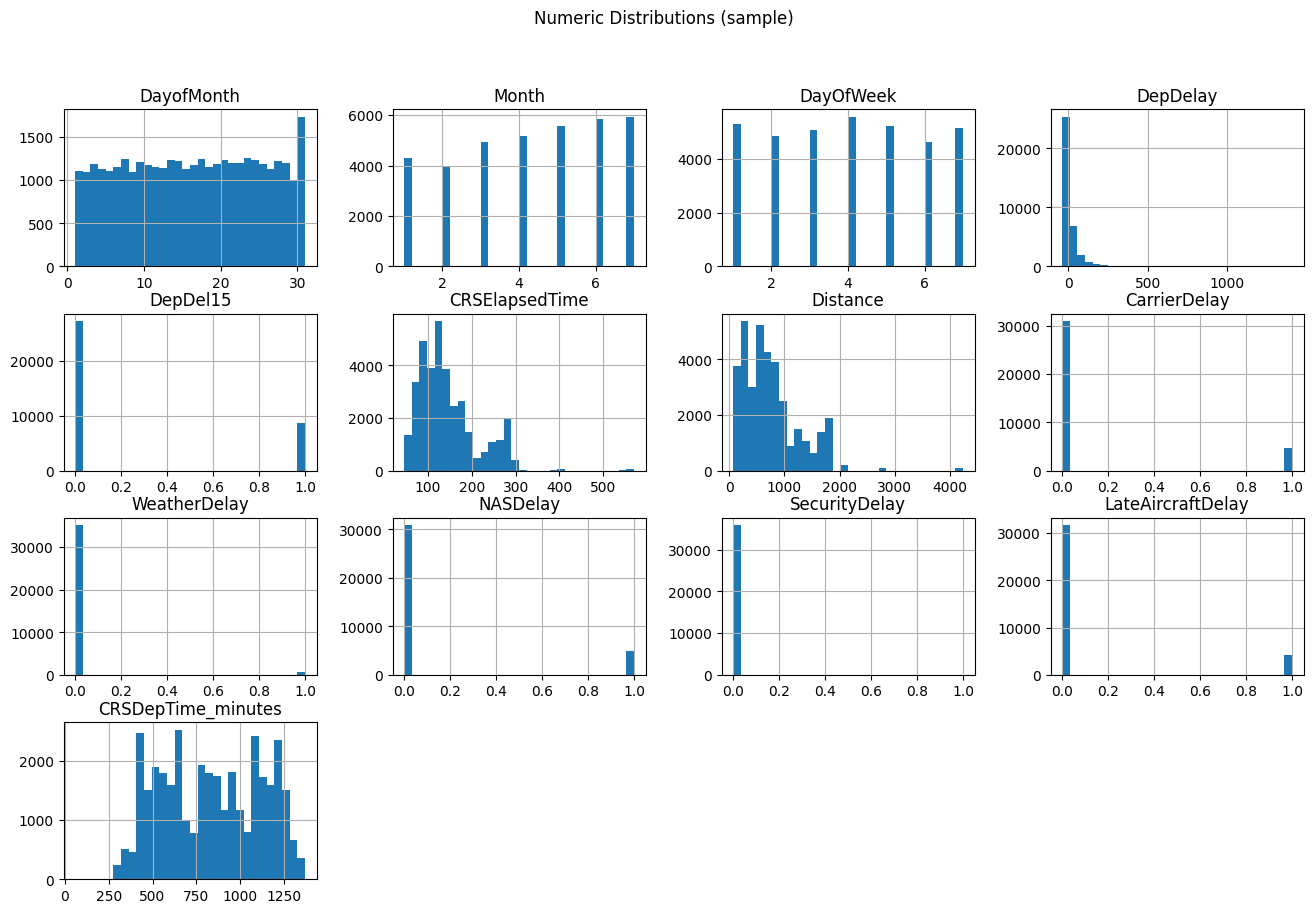

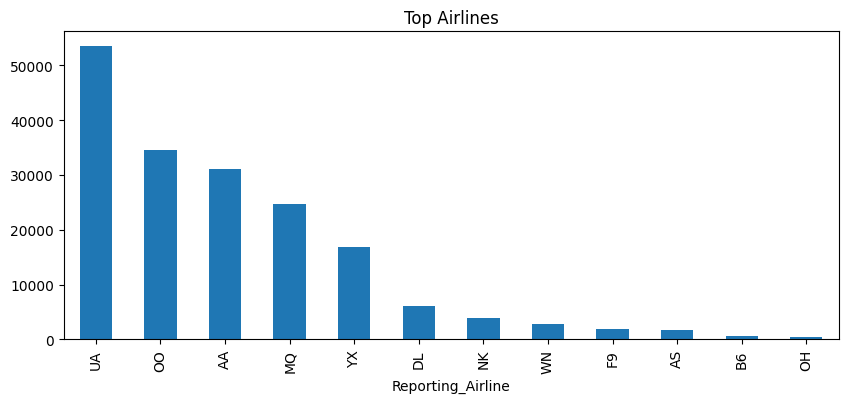

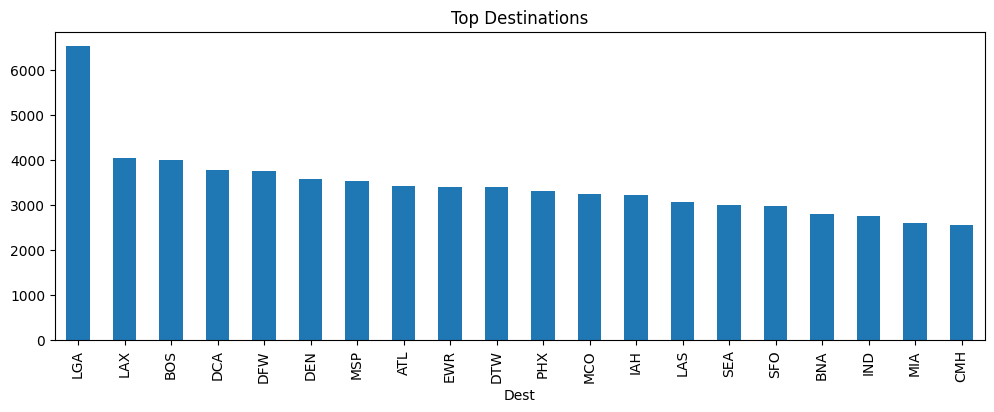

In [ ]:
# Convert a small sample to pandas df for visualization (safer for large dataset)
pandas_sample = df.select(numeric_cols).sample(False, 0.2, seed = 42).toPandas()

# Numeric histograms
pandas_sample.hist(bins = 30, figsize = (16,10))
plt.suptitle("Numeric Distributions (sample)")
plt.show()

# Categorical bar plots
airline_counts = df.groupBy("Reporting_Airline").count().orderBy(F.desc("count")).limit(20).toPandas()
airline_counts.plot.bar(x = "Reporting_Airline", y = "count", legend = False, figsize = (10,4), title = "Top Airlines")
plt.show()

dest_counts = df.groupBy("Dest").count().orderBy(F.desc("count")).limit(20).toPandas()
dest_counts.plot.bar(x = "Dest", y = "count", legend = False, figsize = (12,4), title = "Top Destinations")
plt.show()

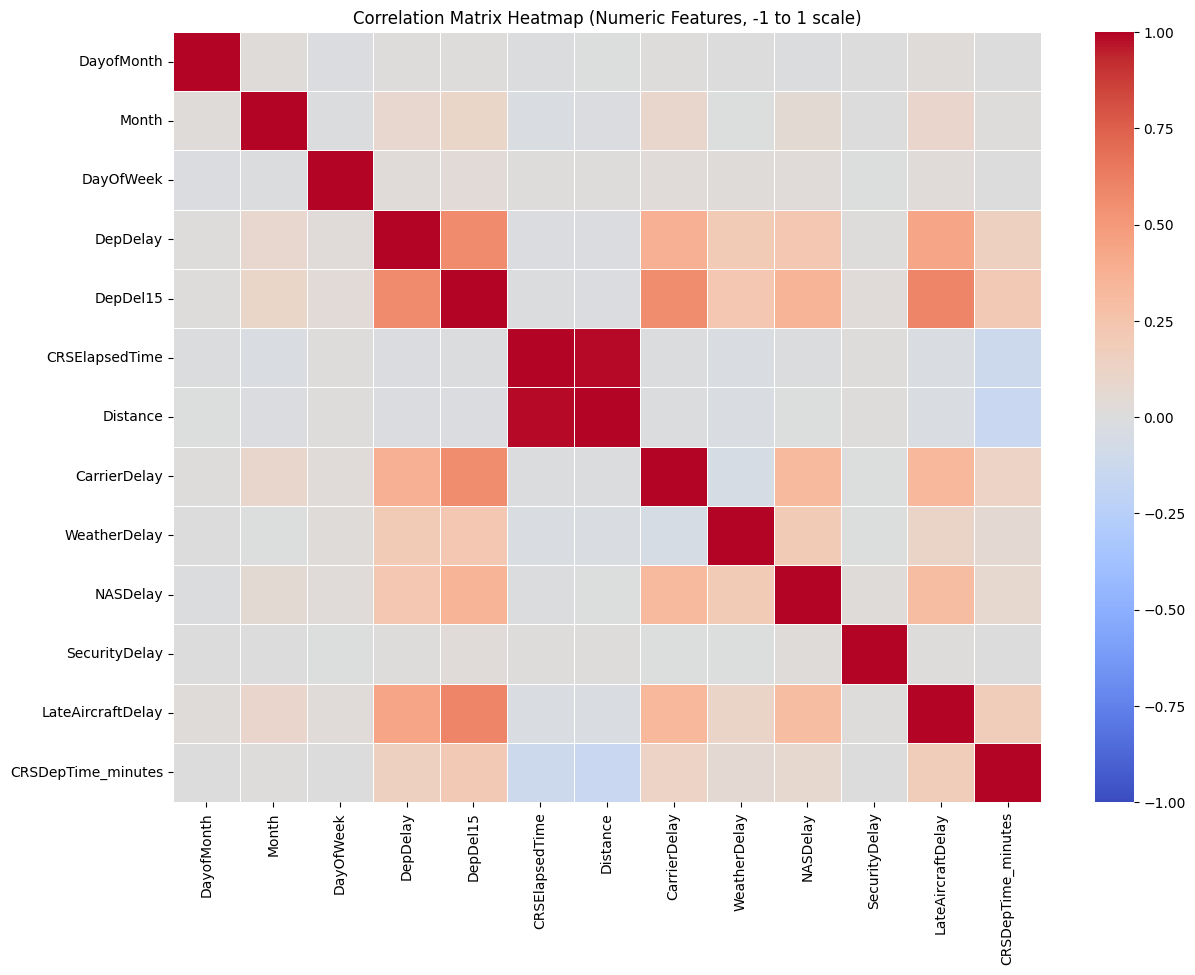

In [ ]:
# Correlation matrix heatmap
for col in numeric_cols:
    df = df.withColumn(col, df[col].cast(DoubleType()))

pdf = df.select(numeric_cols).toPandas()
corr_matrix = pdf.corr()

plt.figure(figsize = (14,10))
sns.heatmap(corr_matrix, cmap = "coolwarm", linewidths = 0.5, vmin = -1, vmax = 1)
plt.title("Correlation Matrix Heatmap (Numeric Features, -1 to 1 scale)")
plt.show()

## Feature Engineering

In [ ]:
# Compute top 10 destinations
top_dest_rows = (
    df.groupBy("Dest")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
      .collect()
)

top_dest_list = [row["Dest"] for row in top_dest_rows]

# Group destinations not in top 10 into "Other"
df = df.withColumn(
    "Dest_simplified",
    F.when(F.col("Dest").isin(top_dest_list), F.col("Dest")).otherwise("Other")
)

df = df.drop("Dest").withColumnRenamed("Dest_simplified", "Dest")

df.select("Dest").distinct().show(truncate = False)

+-----+
|Dest |
+-----+
|BOS  |
|LAX  |
|MSP  |
|EWR  |
|Other|
|DFW  |
|DCA  |
|LGA  |
|DTW  |
|DEN  |
|ATL  |
+-----+



In [ ]:
# Categorical columns to encode
cat_cols = ["Reporting_Airline", "Dest"]

# Numeric columns (all columns except target)
num_cols = [c for c in df.columns if c not in cat_cols + ["DepDel15", "DepDelay"]]

# StringIndexer for categorical columns
indexers = [StringIndexer(inputCol = c, outputCol = c+"_idx", handleInvalid = "keep") for c in cat_cols]

# OneHotEncoder for indexed columns
ohe = OneHotEncoder(
    inputCols = [c+"_idx" for c in cat_cols],
    outputCols = [c+"_ohe" for c in cat_cols],
    dropLast = True
)

# VectorAssembler to combine numeric + one-hot features
assembler = VectorAssembler(
    inputCols = num_cols + [c+"_ohe" for c in cat_cols],
    outputCol = "features"
)

# Modelling

## Logistic Regression

In [ ]:
# Define logistic regression model
lr = LogisticRegression(
    featuresCol = "features",
    labelCol = "DepDel15",
    maxIter = 100,
    regParam = 0.0,
    elasticNetParam = 0.0,
    family = "binomial"
)

# Pipeline: indexing + OHE + assembler + LR
lr_pipeline = Pipeline(stages = indexers + [ohe, assembler, lr])

# Split train/test
train_df, test_df = df.randomSplit([0.8, 0.2], seed = 123)

# Fit model
lr_model = lr_pipeline.fit(train_df)

# Predictions
lr_preds = lr_model.transform(test_df)

Logistic Regression ROC AUC: 0.9148
Accuracy:  0.9141
Precision: 0.8637
Recall:    0.7661
Confusion Matrix:
[[25781  1036]
 [ 2004  6563]]


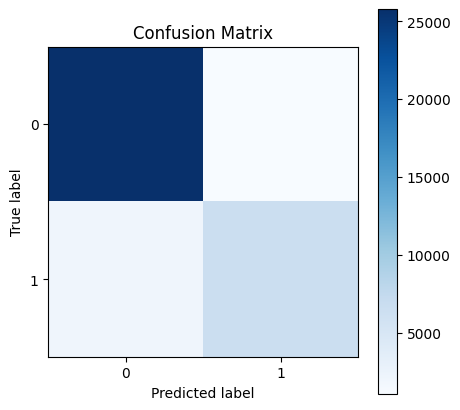

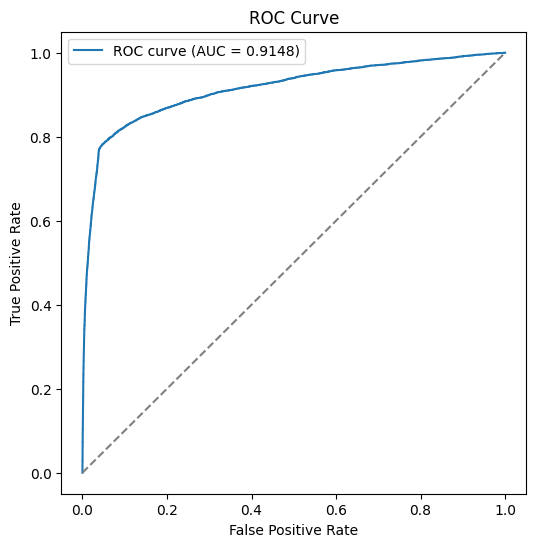

Feature names (numeric or vector columns) with coefficients:
DayofMonth: 0.0010146994262915654
Month: 0.08504748689704568
DayOfWeek: 0.021042303867909364
CRSElapsedTime: 0.01702341894326837
Distance: -0.00199436612107546
CarrierDelay: 3.686276983627319
WeatherDelay: 4.220074319336078
NASDelay: 0.05267494553644258
SecurityDelay: 3.7951591549419397
LateAircraftDelay: 4.737631924019805
CRSDepTime_minutes: 0.0014326478291280744
Reporting_Airline_ohe: 0.03395591663981551
Dest_ohe: 0.015503988055647589


In [ ]:
# Evaluation
bce = BinaryClassificationEvaluator(
    labelCol = "DepDel15",
    rawPredictionCol = "rawPrediction",
    metricName = "areaUnderROC"
)

roc_auc = bce.evaluate(lr_preds)
print(f"Logistic Regression ROC AUC: {roc_auc:.4f}")

# Convert predictions to pandas for detailed metrics
preds_pdf = lr_preds.select("DepDel15", "prediction", "probability").toPandas()
y_true = preds_pdf["DepDel15"].values
y_pred = preds_pdf["prediction"].values
y_proba = np.array([p[1] for p in preds_pdf["probability"]])  # probability of class 1 (delayed > 15 mins)

# Accuracy, precision, recall
accuracy = (y_true == y_pred).mean()
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize = (5,5))
plt.imshow(cm, interpolation = 'nearest', cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,6))
plt.plot(fpr, tpr, label = f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle = "--", color = "gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature importances:
# Get the VectorAssembler stage from pipeline
assembler_stage = [s for s in lr_model.stages if isinstance(s, VectorAssembler)][0]

# Get the input columns to the assembler (numeric + OHE vector columns)
feature_names = assembler_stage.getInputCols()

# Get the raw coefficients
coefficients = lr_model.stages[-1].coefficients.toArray()

# Print numeric columns first
print("Feature names (numeric or vector columns) with coefficients:")
for name, coef in zip(feature_names, coefficients[:len(feature_names)]):
    print(f"{name}: {coef}")

## GBTRegressor (alternative to XGBoost)

In [ ]:
# StringIndexer for categorical features (can't do one-hot encoding this time)
indexers = [StringIndexer(inputCol = c, outputCol = c+"_idx", handleInvalid = "keep") for c in cat_cols]

# Numeric columns (all columns except target)
num_cols = [c for c in numeric_cols if c not in ["DepDelay", "DepDel15"]]

# VectorAssembler
assembler = VectorAssembler(
    inputCols = [c+"_idx" for c in cat_cols] + num_cols,
    outputCol = "features"
)

# Define GBTRegressor
gbt = GBTRegressor(featuresCol = "features", labelCol = "DepDelay", maxIter = 200)

# Pipeline
pipeline = Pipeline(stages = indexers + [assembler, gbt])

# Train/test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed = 123)

# Fit model
gbt_model = pipeline.fit(train_df)

# Make predictions
predictions = gbt_model.transform(test_df)

In [ ]:
# Evaluate
evaluator_rmse = RegressionEvaluator(labelCol = "DepDelay", predictionCol = "prediction", metricName = "rmse")
evaluator_mae = RegressionEvaluator(labelCol = "DepDelay", predictionCol = "prediction", metricName = "mae")
evaluator_r2 = RegressionEvaluator(labelCol = "DepDelay", predictionCol = "prediction", metricName = "r2")

# MAE, RMSE, R^2
mae = evaluator_mae.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"GBT Regressor Performance on Test Set:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:   {r2:.3f}")

# Feature importances:
gbt_stage = gbt_model.stages[-1]  # Last stage in the pipeline is GBTRegressor
importances = gbt_stage.featureImportances.toArray()

# Get the VectorAssembler stage from the fitted pipeline
assembler_stage_gbt = gbt_model.stages[-2]

# Get the input column names directly from the assembler, ensuring correct alignment
feature_names = assembler_stage_gbt.getInputCols()

# Put into df for displaying
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values(by = "Importance", ascending = False)
feat_imp_df

GBT Regressor Performance on Test Set:
MAE:  16.412
RMSE: 44.920
R^2:   0.372


,Feature,Importance
11,LateAircraftDelay,0.166083
2,DayofMonth,0.141280
0,Reporting_Airline_idx,0.132568
12,CRSDepTime_minutes,0.106152
7,CarrierDelay,0.105193
1,Dest_idx,0.066414
8,WeatherDelay,0.057118
5,CRSElapsedTime,0.056411
4,DayOfWeek,0.051200
3,Month,0.046976


# Save Results

In [ ]:
# Save models for later use
output_path = "/content/drive/MyDrive/Colab Notebooks/Data"

lr_model.write().overwrite().save(output_path + "/lr_model")
gbt_model.write().overwrite().save(output_path + "/gbtr_model")

# To load saved models, use:
# from pyspark.ml.pipeline import PipelineModel
# lr_loaded_model = PipelineModel.load(output_path + "/lr_model")
# gbt_loaded_model = PipelineModel.load(output_path + "/gbtr_model")